# Centroid-based propagation speed of the Eddy 

## Goal of the Notebook

This notebook aims at computing the eddy alongshore centroid-based speeds, using the fitted ellipses. These SWOT-based estimates are then compared against velocities derived from conventional altimetry and interpreted with respect to coastal and bathymetric metrics.

## Data

To download the data see the README.md. The user will need to define the paths of the data directories of the folder(s) which holds the data.

## Import modules and open datasets

In [1]:
### IMPORT MODULES ###

import os
from glob import glob
import gc  
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import xarray as xr
import scipy.io
import cartopy
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import matplotlib.patheffects as path_effects
from matplotlib.colors import BoundaryNorm
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.signal import butter, filtfilt
from scipy.interpolate import griddata, interp1d
from shapely.geometry import MultiPoint
from shapely.ops import unary_union, polygonize
from skimage import measure
from scipy.spatial import Delaunay
import geopy.distance
from datetime import datetime, timedelta

In [2]:
### BATHYMETRY ###

datadir_bathy = '/Users/martina/ex_tesi/datasets/bathymetry/'

ds_bathy=xr.open_dataset(datadir_bathy+'MED_GEBCO_30sec.nc')

For SWOT data, it was decided to separate the data in 4 groups in order to facilitate the preprocessing, based on the month (may, june) and on the pass (right n.003, left n.016):

- May, right pass
- May, left pass
- June, right pass
- June, left pass

In [3]:
### SWOT ###

# Directories
datadir_may_right= '/Users/martina/ex_tesi/datasets/swot_data/v_2.0.1/003_may/'
datadir_june_right= '/Users/martina/ex_tesi/datasets/swot_data/v_2.0.1/003_june/'
datadir_may_left= '/Users/martina/ex_tesi/datasets/swot_data/v_2.0.1/016_may/'
datadir_june_left= '/Users/martina/ex_tesi/datasets/swot_data/v_2.0.1/016_june/'

# Dictionary
datasets_may_right = {}
datasets_may_left = {}
datasets_june_right = {}
datasets_june_left = {}

# May right
may_files_right = sorted(glob(os.path.join(datadir_may_right, 'SWOT_L3_LR_SSH_Expert_*_003_202305*_v2.0.1.nc')))
for f in may_files_right:
    date_tag = os.path.basename(f).split('_')[7][:8]
    key = f"ds_003_{date_tag[4:]}"  # -> 'ds_003_0501'
    datasets_may_right[key] = xr.open_dataset(f)

# June right
june_files_right = sorted(glob(os.path.join(datadir_june_right, 'SWOT_L3_LR_SSH_Expert_*_003_202306*_v2.0.1.nc')))
for f in june_files_right:
    date_tag = os.path.basename(f).split('_')[7][:8]
    key = f"ds_003_{date_tag[4:]}"  # -> 'ds_003_0601'
    datasets_june_right[key] = xr.open_dataset(f)

# May left
may_files_left = sorted(glob(os.path.join(datadir_may_left, 'SWOT_L3_LR_SSH_Expert_*_016_202305*_v2.0.1.nc')))
for f in may_files_left:
    date_tag = os.path.basename(f).split('_')[7][:8]
    key = f"ds_016_{date_tag[4:]}"  # -> 'ds_016_0501'
    datasets_may_left[key] = xr.open_dataset(f)

# June left
june_files_left = sorted(glob(os.path.join(datadir_june_left, 'SWOT_L3_LR_SSH_Expert_*_016_202306*_v2.0.1.nc')))
for f in june_files_left:
    date_tag = os.path.basename(f).split('_')[7][:8]
    key = f"ds_016_{date_tag[4:]}"  # -> 'ds_016_0601'
    datasets_june_left[key] = xr.open_dataset(f)

In [4]:
### SWOT NADIR AND SWATHS ###

## Load MAT file
datadir_swot='/Users/martina/ex_tesi/SWOT_coordinates/'
nadir = scipy.io.loadmat(datadir_swot+'swot_calval_hr_Dec2022-v07-nadir.mat')
swath = scipy.io.loadmat(datadir_swot+'swot_calval_hr_Dec2022-v07-swath.mat')

## Print out variable names of file nadir
print("Variable names in the MAT file:")
for key in nadir:
    print(key)

# Access variables in nadir
variable1 = nadir['__header__']
variable2 = nadir['__version__']
variable3 = nadir['__globals__']
variable4 = nadir['lonlat_swot_track_nadir']

## Print out variable names of file swath
print("Variable names in the MAT file:")
for key in swath:
    print(key)

# Access variables in swath
variable5 = swath['__header__']
variable6 = swath['__version__']
variable7 = swath['__globals__']
variable8 = swath['lonlat_swot_track_swath']



# Define latitude and longitude bounds
lat_min, lat_max = 36, 42
lon_min, lon_max = -2, 8

##NADIR

# Extract latitude and longitude data from variable4

lat_nadir = variable4[:, 1]
lon_nadir = variable4[:, 0]


# Initialize empty lists to store filtered latitude and longitude points
filtered_latitudes = []
filtered_longitudes = []

# Loop through latitude and longitude arrays and select points within bounds
for lat, lon in zip(lat_nadir, lon_nadir):
    if lat >= lat_min and lat <= lat_max and lon >= lon_min and lon <= lon_max:
        filtered_latitudes.append(lat)
        filtered_longitudes.append(lon)


#nadir1
selected_lat_nadir1 = filtered_latitudes[:10]
selected_lon_nadir1 = filtered_longitudes[:10]

#nadir2
selected_lat_nadir2 = filtered_latitudes[10:20]
selected_lon_nadir2 = filtered_longitudes[10:20]  

##SWATH

# Extract latitude and longitude data from variable8

lat_swath = variable8[:, 1]
lon_swath = variable8[:, 0]

# Initialize empty lists to store filtered latitude and longitude points
filtered_latitudes_swath = []
filtered_longitudes_swath = []

# Loop through latitude and longitude arrays and select points within bounds
for lat, lon in zip(lat_swath, lon_swath):
    if lat >= lat_min and lat <= lat_max and lon >= lon_min and lon <= lon_max:
        filtered_latitudes_swath.append(lat)
        filtered_longitudes_swath.append(lon)


selected_lat_swath1 = filtered_latitudes_swath[:10]
selected_lon_swath1 = filtered_longitudes_swath[:10]

selected_lat_swath2 = filtered_latitudes_swath[10:20]
selected_lon_swath2 = filtered_longitudes_swath[10:20]

selected_lat_swath3 = filtered_latitudes_swath[20:30]
selected_lon_swath3 = filtered_longitudes_swath[20:30]

selected_lat_swath4 = filtered_latitudes_swath[31:41]
selected_lon_swath4 = filtered_longitudes_swath[31:41]

selected_lat_swath5 = filtered_latitudes_swath[41:51] 
selected_lon_swath5 = filtered_longitudes_swath[41:51]

selected_lat_swath6 = filtered_latitudes_swath[52:62]
selected_lon_swath6 = filtered_longitudes_swath[52:62]

selected_lat_swath7 = filtered_latitudes_swath[62:72]
selected_lon_swath7 = filtered_longitudes_swath[62:72]

selected_lat_swath8 = filtered_latitudes_swath[72:82]
selected_lon_swath8 = filtered_longitudes_swath[72:82]


Variable names in the MAT file:
__header__
__version__
__globals__
lonlat_swot_track_nadir
Variable names in the MAT file:
__header__
__version__
__globals__
lonlat_swot_track_swath


## Preprocessing of the datasets

### Crop SWOT datasets to the area of interest

In [5]:
# Area of interest 
lon_min, lon_max = 1, 5
lat_min, lat_max = 36, 39.5

# Dictionaries for cropped datasets
coastal_may_right = {}
coastal_may_left = {}
coastal_june_right = {}
coastal_june_left = {}

In [6]:
### Function to crop the datasets to the area of interest ###
def crop_datasets(datasets, lon_min, lon_max, lat_min, lat_max):
    cropped_dict = {}
    for key, ds in datasets.items():
        cropped = ds.where(
            (ds['longitude'] > lon_min) & (ds['longitude'] < lon_max) &
            (ds['latitude']  > lat_min) & (ds['latitude']  < lat_max),
            drop=True
        )
        cropped_dict[key] = cropped.load()
        ds.close()
        gc.collect()
    return cropped_dict

In [7]:
# May right
coastal_may_right = crop_datasets(datasets_may_right, lon_min, lon_max, lat_min, lat_max)

In [8]:
# May left
coastal_may_left = crop_datasets(datasets_may_left,  lon_min, lon_max, lat_min, lat_max)

In [9]:
# June right
coastal_june_right = crop_datasets(datasets_june_right, lon_min, lon_max, lat_min, lat_max)

In [10]:
# June left
coastal_june_left = crop_datasets(datasets_june_left,  lon_min, lon_max, lat_min, lat_max)

### Remove mean from SWOT data

In [11]:
### Create ds_* dictionaries with "ssha_filtered" ###

ds_may_right = {}
for key, ds in coastal_may_right.items():
    if key.startswith("ds_003_05"):
        day = key.split("_")[-1]   # es: '0503'
        ds_may_right[f"{day}_r"] = ds["ssha_filtered"]

ds_may_left = {}
for key, ds in coastal_may_left.items():
    if key.startswith("ds_016_05"):
        day = key.split("_")[-1]  
        ds_may_left[f"{day}_l"] = ds["ssha_filtered"]

ds_june_right = {}
for key, ds in coastal_june_right.items():
    if key.startswith("ds_003_06"):
        day = key.split("_")[-1]   
        ds_june_right[f"{day}_r"] = ds["ssha_filtered"]

ds_june_left = {}
for key, ds in coastal_june_left.items():
    if key.startswith("ds_016_06"):
        day = key.split("_")[-1]   
        ds_june_left[f"{day}_l"] = ds["ssha_filtered"]

In [12]:
### Calculate the mean ###
spatial_means_may_right = {k: v.mean(skipna=True) for k, v in ds_may_right.items()}
spatial_means_june_right = {k: v.mean(skipna=True) for k, v in ds_june_right.items()}
spatial_means_may_left = {k: v.mean(skipna=True) for k, v in ds_may_left.items()}
spatial_means_june_left = {k: v.mean(skipna=True) for k, v in ds_june_left.items()}

In [13]:
### Calculate SLA (removing the mean) ###
sla_swot_may_right = {k: ds_may_right[k] - spatial_means_may_right[k] for k in ds_may_right}
sla_swot_june_right = {k: ds_june_right[k] - spatial_means_june_right[k] for k in ds_june_right}
sla_swot_may_left = {k: ds_may_left[k] - spatial_means_may_left[k] for k in ds_may_left}
sla_swot_june_left = {k: ds_june_left[k] - spatial_means_june_left[k] for k in ds_june_left}

## Calculation of Eddy Alongshore Speed

In [14]:
### Upload ellipse parameters ###

save_dir = "/Users/martina/ex_tesi/Notebooks/results_ellipsefit"

names = [
    "508_l","510_l","511_l","512_l","513_l","514_l","516_l","518_l","519_l",
    "523_l","524_l","525_l","529_l","531_l",
    "601_r","603_r","604_r","605_r","607_r","609_r",
    "610_r","611_r","612_r","613_r"
]

models = {}
for name in names:
    params = np.load(os.path.join(save_dir, f"ellipse_{name}.npy"))
    models[name] = type("Model", (), {"params": params})()


### Velocitiy from SWOT 

In [15]:
### SWOT centroids ###
xc_508_l, yc_508_l = models["508_l"].params[:2]
xc_510_l, yc_510_l = models["510_l"].params[:2]
xc_511_l, yc_511_l = models["511_l"].params[:2]
xc_512_l, yc_512_l = models["512_l"].params[:2]
xc_513_l, yc_513_l = models["513_l"].params[:2]
xc_514_l, yc_514_l = models["514_l"].params[:2]
xc_516_l, yc_516_l = models["516_l"].params[:2]
xc_518_l, yc_518_l = models["518_l"].params[:2]
xc_519_l, yc_519_l = models["519_l"].params[:2]
xc_523_l, yc_523_l = models["523_l"].params[:2]
xc_524_l, yc_524_l = models["524_l"].params[:2]
xc_525_l, yc_525_l = models["525_l"].params[:2]
xc_529_l, yc_529_l = models["529_l"].params[:2]
xc_531_l, yc_531_l = models["531_l"].params[:2]
xc_601_r, yc_601_r = models["601_r"].params[:2]
xc_603_r, yc_603_r = models["603_r"].params[:2]
xc_604_r, yc_604_r = models["604_r"].params[:2]
xc_605_r, yc_605_r = models["605_r"].params[:2]
xc_607_r, yc_607_r = models["607_r"].params[:2]
xc_609_r, yc_609_r = models["609_r"].params[:2]
xc_610_r, yc_610_r = models["610_r"].params[:2]
xc_611_r, yc_611_r = models["611_r"].params[:2]
xc_612_r, yc_612_r = models["612_r"].params[:2]
xc_613_r, yc_613_r = models["613_r"].params[:2]

In [16]:
### Create an array with the longitude of swot centroids ###
lon_centroid_swot_array = [xc_508_l, xc_510_l, xc_511_l, xc_512_l, xc_513_l, xc_514_l, xc_516_l, xc_518_l, 
                     xc_519_l, xc_523_l, xc_524_l, xc_525_l, xc_529_l, xc_531_l, xc_601_r, 
                     xc_603_r,  xc_607_r, xc_609_r, xc_610_r, xc_611_r, xc_612_r, xc_613_r]

lon_centroid_swot = np.array(lon_centroid_swot_array)

In [17]:
### Function to calculate velocities from SWOT data ###

def calculate_speed(ds1, ds2, lon_1, lat_1, lon_2, lat_2):
    
    # Find the index of the nearest latitude and longitude in the dataset 1
    lat_index1 = np.unravel_index(np.abs(ds1['latitude'].values - lat_1).argmin(), ds1['latitude'].shape)
    lon_index1 = np.unravel_index(np.abs(ds1['longitude'].values - lon_1).argmin(), ds1['longitude'].shape)

    # Find the index of the nearest latitude and longitude in the dataset 2
    lat_index2 = np.unravel_index(np.abs(ds2['latitude'].values - lat_2).argmin(), ds2['latitude'].shape)
    lon_index2 = np.unravel_index(np.abs(ds2['longitude'].values - lon_2).argmin(), ds2['longitude'].shape)

    # Retrieve the time corresponding to the selected latitude and longitude in dataset 1
    time_at_point1 = ds1['time'].values[lat_index1[0], lon_index1[1]]

    # Retrieve the time corresponding to the selected latitude and longitude in dataset 2
    time_at_point2 = ds2['time'].values[lat_index2[0], lon_index2[1]]

    # Calculate the difference between the two timedelta64 objects in seconds
    difference_seconds = (time_at_point2 - time_at_point1) / np.timedelta64(1, 's')

    # Calculate the great-circle distance between the two points
    point1 = (lat_1, lon_1)
    point2 = (lat_2, lon_2)
    distance_km =  geopy.distance.geodesic(point1, point2).kilometers

    # Calculate speed
    difference_seconds = round(difference_seconds, 0)
    distance_m = distance_km * 1000  # convert km to meters

    total_speed = distance_m / difference_seconds
    total_speed_cms = total_speed * 100  # cm/s

    return total_speed_cms

In [18]:
### SWOT velocities ###
v_8_10_may = calculate_speed(coastal_may_left['ds_016_0508'], coastal_may_left['ds_016_0510'], xc_508_l, yc_508_l, xc_510_l, yc_510_l)
v_10_11_may = calculate_speed(coastal_may_left['ds_016_0510'], coastal_may_left['ds_016_0511'], xc_510_l, yc_510_l, xc_511_l, yc_511_l)
v_11_12_may = calculate_speed(coastal_may_left['ds_016_0511'], coastal_may_left['ds_016_0512'], xc_511_l, yc_511_l, xc_512_l, yc_512_l)
v_12_13_may = calculate_speed(coastal_may_left['ds_016_0512'], coastal_may_left['ds_016_0513'], xc_512_l, yc_512_l, xc_513_l, yc_513_l)
v_13_14_may = calculate_speed(coastal_may_left['ds_016_0513'], coastal_may_left['ds_016_0514'], xc_513_l, yc_513_l, xc_514_l, yc_514_l)
v_14_16_may = calculate_speed(coastal_may_left['ds_016_0514'], coastal_may_left['ds_016_0516'], xc_514_l, yc_514_l, xc_516_l, yc_516_l)
v_16_18_may = calculate_speed(coastal_may_left['ds_016_0516'], coastal_may_left['ds_016_0518'], xc_516_l, yc_516_l, xc_518_l, yc_518_l)
v_18_19_may = calculate_speed(coastal_may_left['ds_016_0518'], coastal_may_left['ds_016_0519'], xc_518_l, yc_518_l, xc_519_l, yc_519_l)
v_19_23_may = calculate_speed(coastal_may_left['ds_016_0519'], coastal_may_left['ds_016_0523'], xc_519_l, yc_519_l, xc_523_l, yc_523_l)
v_23_24_may = calculate_speed(coastal_may_left['ds_016_0523'], coastal_may_left['ds_016_0524'], xc_523_l, yc_523_l, xc_524_l, yc_524_l)
v_24_25_may = calculate_speed(coastal_may_left['ds_016_0524'], coastal_may_left['ds_016_0525'], xc_524_l, yc_524_l, xc_525_l, yc_525_l)
v_25_29_may = calculate_speed(coastal_may_left['ds_016_0525'], coastal_may_left['ds_016_0529'], xc_525_l, yc_525_l, xc_529_l, yc_529_l)
v_29_31_may = calculate_speed(coastal_may_left['ds_016_0529'], coastal_may_left['ds_016_0531'], xc_529_l, yc_529_l, xc_531_l, yc_531_l)
v_31_1_june = calculate_speed(coastal_may_left['ds_016_0531'], coastal_june_right['ds_003_0601'], xc_531_l, yc_531_l, xc_601_r, yc_601_r)
v_1_3_june = calculate_speed(coastal_june_right['ds_003_0601'], coastal_june_right['ds_003_0603'], xc_601_r, yc_601_r, xc_603_r, yc_603_r)
v_3_7_june = calculate_speed(coastal_june_right['ds_003_0603'], coastal_june_right['ds_003_0607'], xc_603_r, yc_603_r, xc_607_r, yc_607_r)
v_3_5_june = calculate_speed(coastal_june_right['ds_003_0603'], coastal_june_right['ds_003_0605'], xc_603_r, yc_603_r, xc_605_r, yc_605_r)
v_7_9_june = calculate_speed(coastal_june_right['ds_003_0607'], coastal_june_right['ds_003_0609'], xc_607_r, yc_607_r, xc_609_r, yc_609_r)
v_9_10_june = calculate_speed(coastal_june_right['ds_003_0609'], coastal_june_right['ds_003_0610'], xc_609_r, yc_609_r, xc_610_r, yc_610_r)
v_10_11_june = calculate_speed(coastal_june_right['ds_003_0610'], coastal_june_right['ds_003_0611'], xc_610_r, yc_610_r, xc_611_r, yc_611_r)
v_11_12_june = calculate_speed(coastal_june_right['ds_003_0611'], coastal_june_right['ds_003_0612'], xc_611_r, yc_611_r, xc_612_r, yc_612_r)
v_12_13_june = calculate_speed(coastal_june_right['ds_003_0612'], coastal_june_right['ds_003_0613'], xc_612_r, yc_612_r, xc_613_r, yc_613_r)

In [19]:
### Create an array with swot velocities ###
velocities_swot= [v_8_10_may, v_10_11_may, v_11_12_may, -v_12_13_may,  ### the minus is needed to account for the fact that 
                            -v_13_14_may, v_14_16_may, v_16_18_may,    ### the centroid is actually moving backwards 
                            v_18_19_may, v_19_23_may, v_23_24_may,
                            v_24_25_may, v_25_29_may, 
                            v_29_31_may, v_31_1_june, v_1_3_june,
                            v_3_7_june, v_7_9_june, v_9_10_june,
                            v_10_11_june, v_11_12_june, v_12_13_june]

In [20]:
np.save("/Users/martina/ex_tesi/datasets/velocities_swot.npy", velocities_swot)

### Velocity from Conventional Altimetry

In [21]:
### Upload file with conventional altimetry PET algorithm results ###
datadir_convalt_pet = "/Users/martina/ex_tesi/py_eddy_tracker/eddy_pos_convalt/"
eddy_pos = pd.read_csv(datadir_convalt_pet + 'eddy_positions_figura_paper.csv')

In [22]:
## Convert coordinates columns to floats ##
eddy_pos["Latitudine"] = eddy_pos["Latitudine"].astype(float)
eddy_pos["Longitudine"] = eddy_pos["Longitudine"].astype(float)

## Compute geodesic distance (km) between consecutive eddy detections ##
distances_km = []
for i in range(len(eddy_pos) - 1):
    coord1 = (eddy_pos.loc[i, "Latitudine"], eddy_pos.loc[i, "Longitudine"])
    coord2 = (eddy_pos.loc[i + 1, "Latitudine"], eddy_pos.loc[i + 1, "Longitudine"])
    distance = geopy.distance.geodesic(coord1, coord2).kilometers
    distances_km.append(distance)

## Add distances to the dataframe (first entry has no previous point) ##
eddy_pos["Distanza_km"] = [None] + distances_km 

## Remove NaN row and extract distances ##
eddy_pos = eddy_pos.dropna()
dist_eddy_km = eddy_pos.Distanza_km.to_numpy()

In [23]:
### Convert distances to propagation velocities (cm/s) ###

## Define typical time intervals between detections
dist_eddy_m = dist_eddy_km * 1000
t_1day = 86400
t_2days = 2 * t_1day
t_3days = 3 * t_1day
t_4days = 4 * t_1day
t_6days = 6 * t_1day

## Compute velocities for each detection interval 
v_8_10_may_convalt = (dist_eddy_m[0] / t_2days)*100
v_10_11_may_convalt = (dist_eddy_m[1] / t_1day)*100
v_11_12_may_convalt = (dist_eddy_m[2] / t_1day)*100
v_12_13_may_convalt = (dist_eddy_m[3] / t_1day)*100
v_13_14_may_convalt = (dist_eddy_m[4] / t_1day)*100
v_14_16_may_convalt = (dist_eddy_m[5] / t_2days)*100
v_16_18_may_convalt = (dist_eddy_m[6] / t_2days)*100
v_18_19_may_convalt = (dist_eddy_m[7] / t_1day)*100
v_19_23_may_convalt = (dist_eddy_m[8] / t_4days)*100
v_23_24_may_convalt = (dist_eddy_m[9] / t_1day)*100
v_24_25_may_convalt = (dist_eddy_m[10] / t_1day)*100
v_25_29_may_convalt = (dist_eddy_m[11] / t_4days)*100
v_29_31_may_convalt = (dist_eddy_m[12] / t_2days)*100
v_31_1_june_convalt = (dist_eddy_m[13] / t_1day)*100
v_1_3_june_convalt = (dist_eddy_m[14] / t_2days)*100
v_3_7_june_convalt = (dist_eddy_m[15] / t_4days)*100
v_7_9_june_convalt = (dist_eddy_m[16] / t_2days)*100
v_9_10_june_convalt = (dist_eddy_m[17] / t_1day)*100
v_10_11_june_convalt = (dist_eddy_m[18] / t_1day)*100
v_11_12_june_convalt = (dist_eddy_m[19] / t_1day)*100
v_12_13_june_convalt = (dist_eddy_m[20] / t_1day)*100

In [24]:
### Create an array with conventional altimetry velocities ###
velocities_convalt = [
    v_8_10_may_convalt, v_10_11_may_convalt, v_11_12_may_convalt, v_12_13_may_convalt,
    v_13_14_may_convalt, v_14_16_may_convalt, v_16_18_may_convalt, v_18_19_may_convalt,
    v_19_23_may_convalt, v_23_24_may_convalt, v_24_25_may_convalt, v_25_29_may_convalt,
    v_29_31_may_convalt, v_31_1_june_convalt, v_1_3_june_convalt,
    v_3_7_june_convalt, v_7_9_june_convalt, v_9_10_june_convalt, v_10_11_june_convalt,
    v_11_12_june_convalt, v_12_13_june_convalt
]

In [25]:
### Create an array with the longitude of conventional altimetry centroids ###
lon_pet_convalt = eddy_pos.Longitudine.to_numpy()

## Metrics: 1) distance coast-200m isobath; 2) distance between the 200m and 2000m isobaths

In [26]:
### Extract elevation from bathymetry dataset ###
bathymetry = ds_bathy['elevation'].values
lat = ds_bathy['lat'].values
lon = ds_bathy['lon'].values

# Set limits
mask_lon = (lon >= 1) & (lon <= 5)
mask_lat = (lat >= 36) & (lat <= 37.5)

bathymetry_filt = bathymetry[np.ix_(mask_lat, mask_lon)]
lon_filt = lon[mask_lon]
lat_filt = lat[mask_lat]

In [27]:
### Function to convert contour indices (row, col) to geographic coordinates ###
def idx_to_latlon(idx_coords, lat_array, lon_array):
    """
    idx_coords: Nx2 array (row, column)
    lat_array: latitudes array  
    lon_array: longitudes array
    """
    lats = lat_array[idx_coords[:, 0].astype(int)]
    lons = lon_array[idx_coords[:, 1].astype(int)] 

    return np.vstack((lons, lats)).T 

In [28]:
### Extract contours of key isobaths (20m, 200m, 2000m) ###

contours_20_idx = measure.find_contours(bathymetry_filt, level=-20)
contours_200_idx = measure.find_contours(bathymetry_filt, level=-200)
contours_2000_idx = measure.find_contours(bathymetry_filt, level=-2000)

contours_20 = np.vstack([idx_to_latlon(c, lat_filt, lon_filt) for c in contours_20_idx])
contours_200 = np.vstack([idx_to_latlon(c, lat_filt, lon_filt) for c in contours_200_idx])
contours_2000 = np.vstack([idx_to_latlon(c, lat_filt, lon_filt) for c in contours_2000_idx])

In [29]:
### Coast–200 m distance ###

lons_20 = contours_20[:, 0]
lats_20 = contours_20[:, 1]

lons_200 = contours_200[:, 0]
lats_200 = contours_200[:, 1]

# For each coastline point, find the nearest 200 m point in longitude
idx_closest = np.argmin(np.abs(lons_20[:, None] - lons_200[None, :]), axis=1)

distances_km = []
for i in range(len(lons_20)):
    p1 = (lats_20[i], lons_20[i])
    p2 = (lats_200[idx_closest[i]], lons_200[idx_closest[i]])
    distances_km.append(geopy.distance.distance(p1, p2).km)

distances_km = np.array(distances_km)
lons_20_filt = np.array(lons_20)

In [30]:
### Interpolate shelf width to the centroid longitudes of SWOT ellipses ###
f_interp = interp1d(lons_20, distances_km, kind='linear', fill_value="extrapolate")
distances_interp = f_interp(lon_centroid_swot)
array_distances_km = np.array(distances_interp)

In [31]:
np.save("/Users/martina/ex_tesi/datasets/distances_km_v2.npy", array_distances_km)

In [32]:
### 200 m – 2000 m distance (steepness) ###

lons_2000 = contours_2000[:, 0]
lats_2000 = contours_2000[:, 1]

idx_closest_sharpness_2000 = np.argmin(np.abs(lons_200[:, None] - lons_2000[None, :]), axis=1)

sharpness_km_2000 = []
for i in range(len(lons_200)):
    p1 = (lats_200[i],   lons_200[i])
    p2 = (lats_2000[idx_closest_sharpness_2000[i]], lons_2000[idx_closest_sharpness_2000[i]])
    sharpness_km_2000.append(geopy.distance.distance(p1, p2).km)

sharpness_km_2000 = np.array(sharpness_km_2000)
#lons_200_filt = np.array(lons_200)

In [33]:
### Interpolate slope steepness to SWOT ellipse longitudes ###
f_interp_sharp = interp1d(lons_200, sharpness_km_2000, kind='linear', fill_value="extrapolate")
distances_interp_sharpness_2000 = f_interp_sharp(lon_centroid_swot)
array_distances_km_sharp_2000 = np.array(distances_interp_sharpness_2000)

In [34]:
np.save("/Users/martina/ex_tesi/datasets/distances_km_sharp_2000_v2.npy", array_distances_km_sharp_2000)

# Final Figure: Contour-based speed of the Eddy

In [35]:
### Define the date range for the calculation of velocities ###
date_ranges = [('5-08', '5-10'), ('5-10', '5-11'), ('5-11', '5-12'),
                          ('5-12', '5-13'), ('5-13', '5-14'), ('5-14', '5-16'),
                          ('5-16', '5-18'), ('5-18', '5-19'), ('5-19', '5-23'),
                          ('5-23', '5-24'), ('5-24', '5-25'), 
                          ('5-25', '5-29'), ('5-29', '5-31'), ('5-31', '6-01'),
                          ('6-01', '6-03'), ('6-03', '6-07'), ('6-07', '6-09'),
                          ('6-09', '6-10'), ('6-10', '6-11'), ('6-11', '6-12'),
                          ('6-12', '6-13')]

dates = [(datetime.strptime(start, "%m-%d") + (datetime.strptime(end, "%m-%d") - datetime.strptime(start, "%m-%d")) / 2)
                 for start, end in date_ranges]

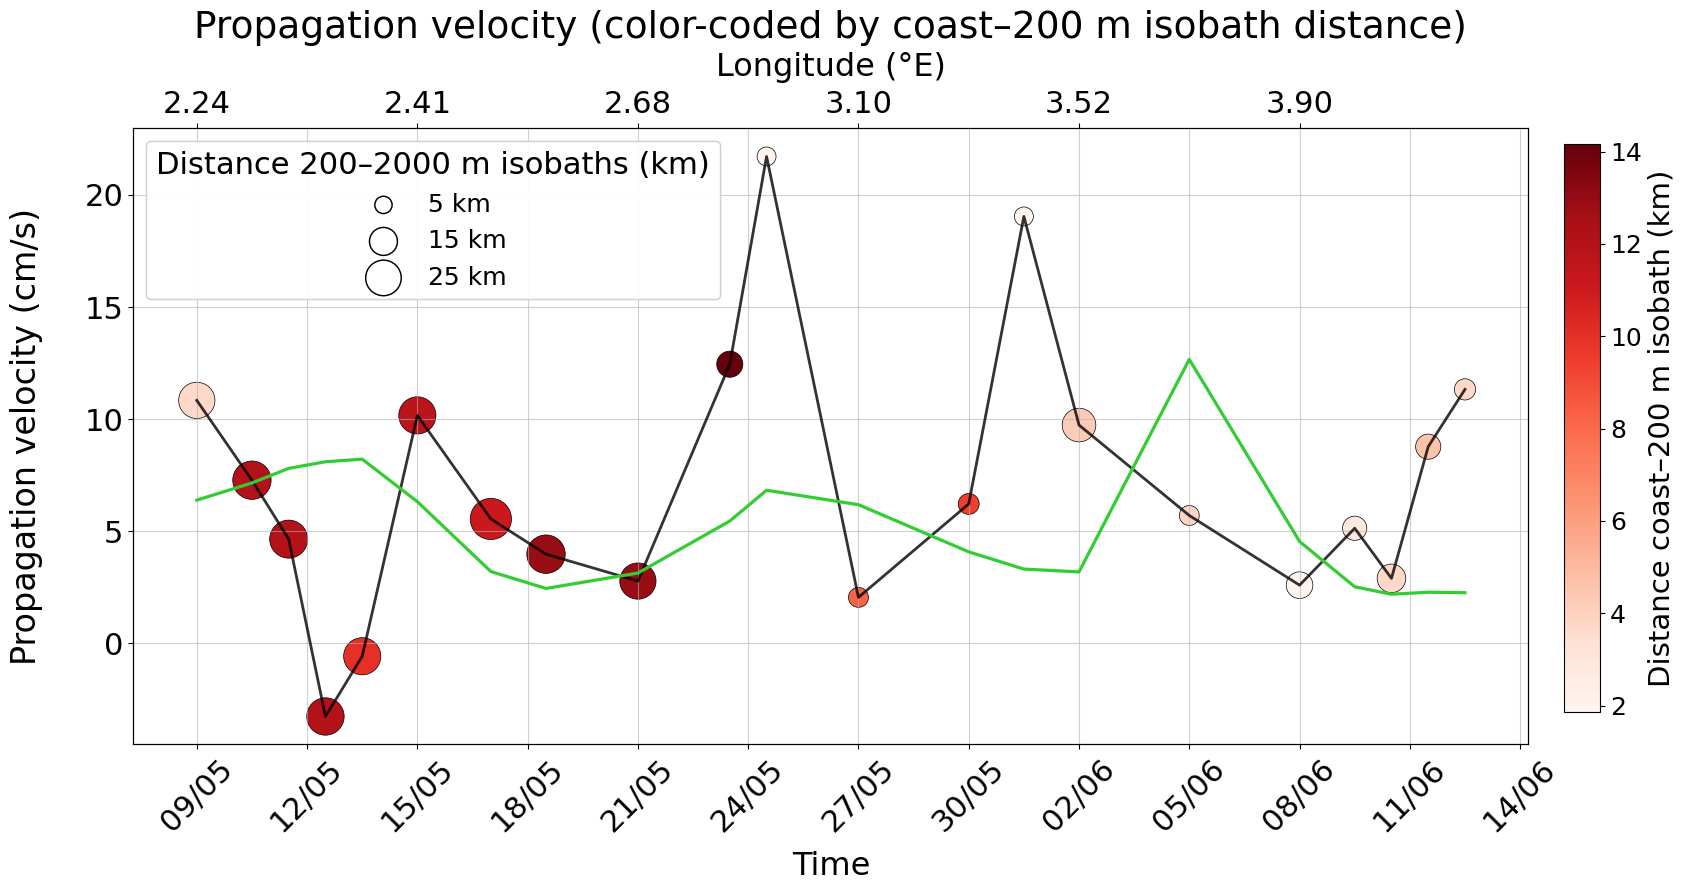

In [36]:
fig, ax = plt.subplots( figsize=(18, 8))

# Axis labels
ax.set_xlabel("Time", fontsize=23, labelpad=10)
ax.set_ylabel("Propagation velocity (cm/s)", fontsize=24, labelpad=30)
ax.set_title("Propagation velocity (color-coded by coast–200 m isobath distance)",
              fontsize=27, pad=10)

# Format x-axis for dates
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax.tick_params(axis='x', rotation=45, labelsize=23)
ax.tick_params(labelsize=22)

ax.grid(True, linestyle="-", alpha=0.6)

# Marker sizes based on isobath-sharpness metric
marker_sizes = 50 + (array_distances_km_sharp_2000[:-1] ** 1.4) * 7

# Scatter
sc = ax.scatter(
    dates, velocities_swot,
    c=array_distances_km[:-1], cmap="Reds",
    s=marker_sizes,
    edgecolor="k", linewidth=0.5
)

# SWOT and conventional altimetry velocities
ax.plot(dates, velocities_swot, color="k", linewidth=2, alpha=0.8, label="SWOT")
ax.plot(dates, velocities_convalt, color="limegreen", linewidth=2.3, label="Conventional Altimetry")

# Twin x-axis for longitude
ax4 = ax.twiny()
ax4.set_xlim(ax.get_xlim())
tick_indices = [0, 5, 8, 11, 14, 16]
ax4.set_xticks([dates[idx] for idx in tick_indices])
ax4.set_xticklabels(["2.24", "2.41", "2.68", "3.10", "3.52", "3.90"],
                    fontsize=22, color='k')
ax4.set_xlabel("Longitude (°E)", fontsize=23, labelpad=10)

# Colorbar for coast–200m distance
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.71])
cbar = plt.colorbar(sc, cax=cbar_ax)
cbar.set_label("Distance coast–200 m isobath (km)", fontsize=21)
cbar.ax.tick_params(labelsize=18)

# Legends
line_handles, line_labels = ax.get_legend_handles_labels()
line_handles = [h for h in line_handles if isinstance(h, Line2D)]
ax.legend(handles=line_handles, loc="upper right", fontsize=20)

# Marker-size legend (200–2000m distance)
legend_sizes_km = [5, 15, 25]
legend_markers = [
    ax.scatter([], [], c="None", s=30 + km*25, edgecolor="k", label=f"{km} km")
    for km in legend_sizes_km
]
size_legend = ax.legend(
    handles=legend_markers, title="Distance 200–2000 m isobaths (km)",
    title_fontsize=22, loc="upper left", fontsize=18, frameon=True
)
ax.add_artist(size_legend)

plt.show()